In [1]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
from tqdm import tqdm

In [2]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# ----- Config -----


CHECKPOINT_PATH = "checkpoints/densenet_cancer_checkpoint.pt"

BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
os.makedirs("checkpoints", exist_ok=True)


In [9]:
class CancerDataset(Dataset):
    def __init__(self, df_or_csv, img_dir, transform=None):
        # Nếu là dataframe thì dùng luôn, nếu là path thì đọc CSV
        if isinstance(df_or_csv, pd.DataFrame):
            self.df = df_or_csv
        else:
            self.df = pd.read_csv(df_or_csv)
        self.img_dir = img_dir
        self.transform = transform or transforms.ToTensor()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]["id"]
        label = self.df.iloc[idx]["label"]
        img_path = os.path.join(self.img_dir, f"{img_id}.tif")
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)


In [10]:
df = pd.read_csv(CSV_PATH)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

train_ds = CancerDataset(train_df, IMG_DIR)
val_ds = CancerDataset(val_df, IMG_DIR)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)


In [11]:
model = models.densenet121(pretrained=True)
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 1)
model = model.to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

start_epoch = 0
best_val_loss = float('inf')

# Resume nếu có checkpoint
if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint["best_val_loss"]
    print(f"🔄 Resumed from epoch {start_epoch}, val_loss={best_val_loss:.4f}")
else:
    print("🚀 Starting fresh training...")


/Users/giangluong/opt/anaconda3/envs/gianglt/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/giangluong/opt/anaconda3/envs/gianglt/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


🚀 Starting fresh training...


In [12]:
for epoch in range(start_epoch, EPOCHS):
    model.train()
    train_loss = 0
    for imgs, labels in tqdm(train_dl, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).view(-1, 1)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # --- Validation ---
    model.eval()
    val_loss, correct = 0, 0
    with torch.no_grad():
        for imgs, labels in val_dl:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).view(-1, 1)
            outputs = model(imgs)
            val_loss += criterion(outputs, labels).item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()

    avg_train_loss = train_loss / len(train_dl)
    avg_val_loss = val_loss / len(val_dl)
    val_acc = correct / len(val_ds)

    print(f"📊 Epoch {epoch+1}/{EPOCHS} | TrainLoss={avg_train_loss:.4f} | ValLoss={avg_val_loss:.4f} | ValAcc={val_acc:.4f}")

    # --- Save checkpoint if improved ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_val_loss": best_val_loss
        }, CHECKPOINT_PATH)
        print(f"💾 Saved checkpoint at epoch {epoch+1} (ValLoss improved to {best_val_loss:.4f})")


Epoch 1/20: 100%|██████████| 440/440 [53:19<00:00,  7.27s/it]


📊 Epoch 1/20 | TrainLoss=0.3411 | ValLoss=0.3044 | ValAcc=0.8713
💾 Saved checkpoint at epoch 1 (ValLoss improved to 0.3044)


Epoch 2/20: 100%|██████████| 440/440 [55:12<00:00,  7.53s/it] 


📊 Epoch 2/20 | TrainLoss=0.2125 | ValLoss=0.2655 | ValAcc=0.8924
💾 Saved checkpoint at epoch 2 (ValLoss improved to 0.2655)


Epoch 3/20: 100%|██████████| 440/440 [51:01<00:00,  6.96s/it]


...

📊 Epoch 18/20 | TrainLoss=0.0106 | ValLoss=0.4807 | ValAcc=0.8983


Epoch 19/20: 100%|██████████| 440/440 [47:43<00:00,  6.51s/it] 


📊 Epoch 19/20 | TrainLoss=0.0184 | ValLoss=0.6145 | ValAcc=0.8847


Epoch 20/20: 100%|██████████| 440/440 [49:46<00:00,  6.79s/it]


📊 Epoch 20/20 | TrainLoss=0.0193 | ValLoss=0.4672 | ValAcc=0.8938


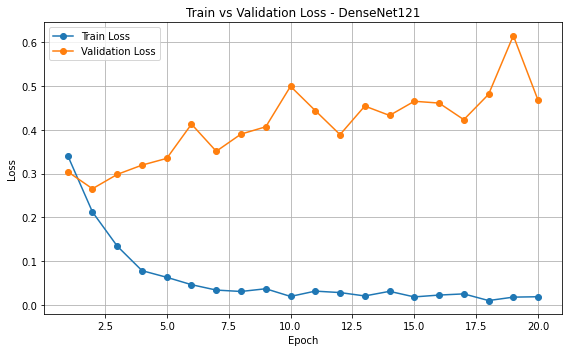

In [11]:
import matplotlib.pyplot as plt

# Loss theo log cậu đưa
train_losses = [
    0.3411, 0.2125, 0.1347, 0.0788, 0.0636,
    0.0468, 0.0345, 0.0313, 0.0375, 0.0200,
    0.0321, 0.0288, 0.0211, 0.0316, 0.0189,
    0.0231, 0.0258, 0.0106, 0.0184, 0.0193
]

val_losses = [
    0.3044, 0.2655, 0.2982, 0.3193, 0.3347,
    0.4128, 0.3509, 0.3901, 0.4067, 0.4990,
    0.4436, 0.3889, 0.4540, 0.4326, 0.4649,
    0.4608, 0.4230, 0.4807, 0.6145, 0.4672
]

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, val_losses, marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss - DenseNet121')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:


SAVE_PATH = "models/densenet_cancer_final.pt"
os.makedirs("models", exist_ok=True)

torch.save(model.state_dict(), SAVE_PATH)
print(f"💾 Model saved successfully → {SAVE_PATH}")


💾 Model saved successfully → models/densenet_cancer_final.pt


In [5]:
DATA_DIR = "/Users/giangluong/Desktop/MasterDS/SEMESTER3/cd3/seminar_4/data/prepared_data"


TEST_DIR = os.path.join(DATA_DIR, "test")
TEST_CSV = os.path.join(DATA_DIR, "test_labels.csv")

class TestDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform or transforms.ToTensor()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]["id"]
        img_path = os.path.join(self.img_dir, f"{img_id}.tif")
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img_id, img

test_ds = TestDataset(TEST_CSV, TEST_DIR)
test_dl = DataLoader(test_ds, batch_size=32, shuffle=False)


In [16]:
import torch

results = []

with torch.no_grad():
    for img_ids, imgs in tqdm(test_dl, desc="Predicting on test set"):
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs = torch.sigmoid(outputs).squeeze().cpu().numpy()
        for img_id, prob in zip(img_ids, probs):
            results.append({"id": img_id, "label": float(prob > 0.5), "probability": float(prob)})


Predicting on test set: 100%|██████████| 138/138 [05:59<00:00,  2.61s/it]


In [17]:
pred_df = pd.DataFrame(results)
pred_df.to_csv("predictions_test.csv", index=False)
print("✅ Predictions saved → predictions_test.csv")
print(pred_df.head())


✅ Predictions saved → predictions_test.csv
                                         id  label   probability
0  c0596dc779612db5477d6a2e3770d61732c202e7    1.0  9.999365e-01
1  13682039e848c6e473c54619365b23ffcab50e2c    1.0  1.000000e+00
2  c15f7233e2e9b87fe7297f72329199a6527fd7a9    0.0  7.482407e-07
3  540ee2788f05d170ab314cf30e5227275b9e1a3d    0.0  7.884674e-06
4  d9f4cdcfd9b2a7195d5c8d1a17905090b79bd75f    0.0  2.419446e-01


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Paths
pred_path = "/Users/giangluong/Desktop/MasterDS/SEMESTER3/cd3/seminar_4/test_predictions_densenet121.csv"
true_path = "data/prepared_data/test_labels.csv"

# Đọc file
pred_df = pd.read_csv(pred_path)
true_df = pd.read_csv(true_path)

# Đảm bảo tên cột đúng (id, label)
print(pred_df.head())
print(true_df.head())

# Merge theo id
df = true_df.merge(pred_df, on="id", suffixes=("_true", "_pred"))

# Giả định: label_pred đang là score/prob (0.0 - 1.0 hoặc logit)
y_true = df["label_true"].astype(int)
y_score = df["label_pred"].astype(float)

# Nếu y_score là logit, có thể sigmoid trước (tuỳ cậu lưu gì)
# from scipy.special import expit
# y_score = expit(y_score)

# Threshold 0.5 để ra nhãn dự đoán
y_pred = (y_score >= 0.5).astype(int)


                                         id  label
0  c0596dc779612db5477d6a2e3770d61732c202e7    1.0
1  13682039e848c6e473c54619365b23ffcab50e2c    1.0
2  c15f7233e2e9b87fe7297f72329199a6527fd7a9    0.0
3  540ee2788f05d170ab314cf30e5227275b9e1a3d    0.0
4  d9f4cdcfd9b2a7195d5c8d1a17905090b79bd75f    0.0
                                         id  label
0  c0596dc779612db5477d6a2e3770d61732c202e7      1
1  13682039e848c6e473c54619365b23ffcab50e2c      1
2  c15f7233e2e9b87fe7297f72329199a6527fd7a9      0
3  540ee2788f05d170ab314cf30e5227275b9e1a3d      0
4  d9f4cdcfd9b2a7195d5c8d1a17905090b79bd75f      0


In [7]:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_score)

print("=== Metrics on test set ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

print("\n=== Classification report ===")
print(classification_report(y_true, y_pred, digits=4))


=== Metrics on test set ===
Accuracy  : 0.9057
Precision : 0.8825
Recall    : 0.8850
F1-score  : 0.8837
ROC-AUC   : 0.9024

=== Classification report ===
              precision    recall  f1-score   support

           0     0.9216    0.9198    0.9207      2619
           1     0.8825    0.8850    0.8837      1782

    accuracy                         0.9057      4401
   macro avg     0.9020    0.9024    0.9022      4401
weighted avg     0.9057    0.9057    0.9057      4401



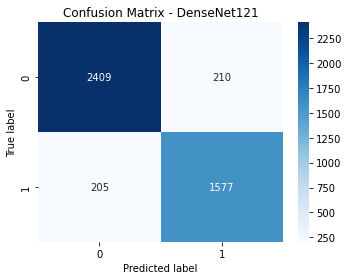

In [8]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - DenseNet121")
plt.tight_layout()
plt.show()


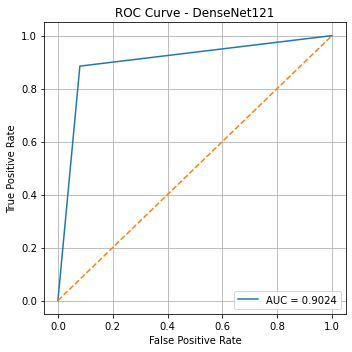

In [9]:
fpr, tpr, thresholds = roc_curve(y_true, y_score)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DenseNet121")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


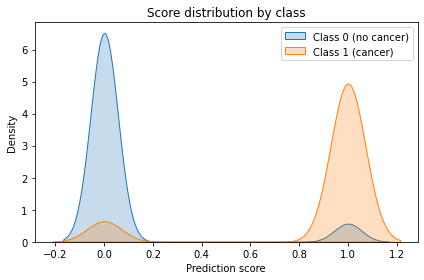

In [10]:
plt.figure(figsize=(6,4))
sns.kdeplot(x=y_score[y_true == 0], label="Class 0 (no cancer)", fill=True)
sns.kdeplot(x=y_score[y_true == 1], label="Class 1 (cancer)", fill=True)
plt.xlabel("Prediction score")
plt.ylabel("Density")
plt.title("Score distribution by class")
plt.legend()
plt.tight_layout()
plt.show()


# 2. Vision Transformer

In [22]:
import os
import torch
import torch.nn as nn
import pandas as pd
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader

# === CONFIG ===
DATA_DIR = "/Users/giangluong/Desktop/MasterDS/SEMESTER3/cd3/seminar_4/data/prepared_data"
CSV_PATH = os.path.join(DATA_DIR, "train_labels.csv")
IMG_DIR = os.path.join(DATA_DIR, "train")
CHECKPOINT_PATH = "checkpoints/vit_s16_cancer.pt"

BATCH_SIZE = 32
EPOCHS = 20
LR = 3e-5
EARLY_STOPPING_PATIENCE = 4

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
os.makedirs("checkpoints", exist_ok=True)

print(f"🚀 Using device: {DEVICE}")


🚀 Using device: cpu


In [23]:
 class CancerDataset(Dataset):
    def __init__(self, df_or_csv, img_dir, transform=None):
        if isinstance(df_or_csv, pd.DataFrame):
            self.df = df_or_csv
        else:
            self.df = pd.read_csv(df_or_csv)
        self.img_dir = img_dir
        self.transform = transform or transforms.ToTensor()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]["id"]
        label = self.df.iloc[idx]["label"]
        img_path = os.path.join(self.img_dir, f"{img_id}.tif")
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)


In [24]:
df = pd.read_csv(CSV_PATH)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

train_dl = DataLoader(CancerDataset(train_df, IMG_DIR, transform=train_tfms), batch_size=BATCH_SIZE, shuffle=True)
val_dl = DataLoader(CancerDataset(val_df, IMG_DIR, transform=val_tfms), batch_size=BATCH_SIZE, shuffle=False)


In [26]:
from torchvision.models import vit_b_16, ViT_B_16_Weights

weights = ViT_B_16_Weights.IMAGENET1K_V1
model = vit_b_16(weights=weights)

# Thay đầu ra để phù hợp binary classification
num_features = model.heads.head.in_features
model.heads.head = nn.Linear(num_features, 1)


model = model.to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5)


In [27]:
start_epoch = 0
best_val_loss = float("inf")
patience_counter = 0

if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_loss = checkpoint["best_val_loss"]
    patience_counter = checkpoint.get("patience_counter", 0)
    print(f"🔁 Resumed from epoch {start_epoch}, best_val_loss={best_val_loss:.4f}")
else:
    print("✨ Starting fresh training...")


✨ Starting fresh training...


In [31]:
from torch.cuda.amp import autocast, GradScaler  # Dù là mps vẫn dùng được fallback này

scaler = GradScaler()

for epoch in range(start_epoch, EPOCHS):
    model.train()
    train_loss = 0.0

    for imgs, labels in tqdm(train_dl, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).view(-1, 1)
        optimizer.zero_grad()

        with autocast():  # không cần device_type ở bản cũ
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss, correct = 0.0, 0

    with torch.no_grad():
        for imgs, labels in val_dl:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).view(-1, 1)
            outputs = model(imgs)
            val_loss += criterion(outputs, labels).item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()

    avg_train_loss = train_loss / len(train_dl)
    avg_val_loss = val_loss / len(val_dl)
    val_acc = correct / len(val_dl.dataset)

    scheduler.step(avg_val_loss)
    print(f"📊 Epoch {epoch+1}/{EPOCHS} | TrainLoss={avg_train_loss:.4f} | ValLoss={avg_val_loss:.4f} | ValAcc={val_acc:.4f}")

    # Checkpoint logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_val_loss": best_val_loss,
            "patience_counter": patience_counter
        }, CHECKPOINT_PATH)
        print(f"💾 Saved best model at epoch {epoch+1} (ValLoss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"⏳ No improvement ({patience_counter}/{EARLY_STOPPING_PATIENCE})")

    # Early stopping
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print("🛑 Early stopping triggered.")
        break

    if DEVICE.type == "mps":
        torch.mps.empty_cache()


/Users/giangluong/opt/anaconda3/envs/gianglt/lib/python3.8/site-packages/torch/cuda/amp/grad_scaler.py:118: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn("torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.")
Epoch 1/20:   0%|          | 0/440 [00:00<?, ?it/s]/Users/giangluong/opt/anaconda3/envs/gianglt/lib/python3.8/site-packages/torch/amp/autocast_mode.py:202: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn('User provided device_type of \'cuda\', but CUDA is not available. Disabling')


📊 Epoch 1/20 | TrainLoss=0.2942 | ValLoss=0.2262 | ValAcc=0.9083
💾 Saved best model at epoch 1 (ValLoss=0.2262)


📊 Epoch 2/20 | TrainLoss=0.2069 | ValLoss=0.2354 | ValAcc=0.9020
⏳ No improvement (1/4)


📊 Epoch 3/20 | TrainLoss=0.1734 | ValLoss=0.1882 | ValAcc=0.9259
💾 Saved best model at epoch 3 (ValLoss=0.1882)


📊 Epoch 4/20 | TrainLoss=0.1390 | ValLoss=0.1933 | ValAcc=0.9281
⏳ No improvement (1/4)


...

📊 Epoch 6/20 | TrainLoss=0.1011 | ValLoss=0.1876 | ValAcc=0.9392
💾 Saved best model at epoch 6 (ValLoss=0.1876)


📊 Epoch 7/20 | TrainLoss=0.0869 | ValLoss=0.2150 | ValAcc=0.9267
⏳ No improvement (1/4)


📊 Epoch 8/20 | TrainLoss=0.0800 | ValLoss=0.2060 | ValAcc=0.9296
⏳ No improvement (2/4)


📊 Epoch 9/20 | TrainLoss=0.0638 | ValLoss=0.2823 | ValAcc=0.9202
⏳ No improvement (3/4)


KeyboardInterrupt: 

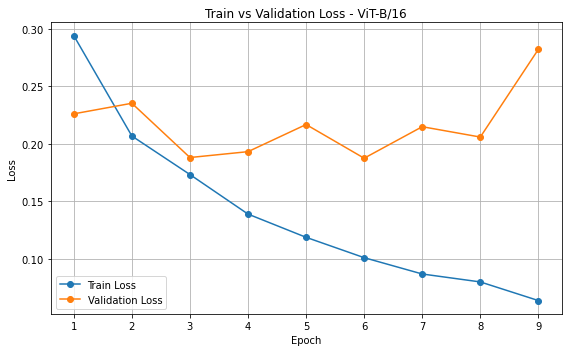

In [17]:
import matplotlib.pyplot as plt

train_losses = [
    0.2942, 0.2069, 0.1734, 0.1390, 0.1188,
    0.1011, 0.0869, 0.0800, 0.0638
]

val_losses = [
    0.2262, 0.2354, 0.1882, 0.1933, 0.2169,
    0.1876, 0.2150, 0.2060, 0.2823
]

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, val_losses, marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss - ViT-B/16')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [33]:
TEST_CSV = os.path.join(DATA_DIR, "test_labels.csv")
TEST_DIR = os.path.join(DATA_DIR, "test")

class TestDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform or transforms.ToTensor()
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]["id"]
        img_path = os.path.join(self.img_dir, f"{img_id}.tif")
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        return img_id, img

test_dl = DataLoader(TestDataset(TEST_CSV, TEST_DIR, transform=val_tfms), batch_size=BATCH_SIZE, shuffle=False)

model.eval()
results = []
with torch.no_grad():
    for img_ids, imgs in tqdm(test_dl, desc="Predicting on test set"):
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs = torch.sigmoid(outputs).squeeze().cpu().numpy()
        for img_id, prob in zip(img_ids, probs):
            results.append({"id": img_id, "label": int(prob > 0.5), "probability": float(prob)})

pred_df = pd.DataFrame(results)
pred_df.to_csv("predictions_vit_s16.csv", index=False)
print("✅ Saved predictions → predictions_vit_s16.csv")


Predicting on test set: 100%|██████████| 138/138 [1:27:28<00:00, 38.03s/it]


✅ Saved predictions → predictions_vit_s16.csv


In [34]:
import pandas as pd

# Đọc file gốc
df = pd.read_csv("predictions_densenet121.csv")

# Tạo file test_predictions_densenet121.csv chỉ gồm id và label
df[['id', 'label']].to_csv("test_predictions_densenet121.csv", index=False)

# Tạo file test_prob_densenet121.csv chỉ gồm id và probability
df[['id', 'probability']].rename(columns={'probability': 'prob'}).to_csv("test_prob_densenet121.csv", index=False)


In [37]:
import pandas as pd

# Đọc file gốc
df = pd.read_csv("predictions_vit_s16.csv")

# Tạo file test_predictions_densenet121.csv chỉ gồm id và label
df[['id', 'label']].to_csv("test_predictions_vit_s16.csv", index=False)

# Tạo file test_prob_densenet121.csv chỉ gồm id và probability
df[['id', 'probability']].rename(columns={'probability': 'prob'}).to_csv("test_prob_vit_s16.csv", index=False)


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Paths
pred_path = "/Users/giangluong/Desktop/MasterDS/SEMESTER3/cd3/seminar_4/test_predictions_vit_s16.csv"
true_path = "data/prepared_data/test_labels.csv"

# Đọc file
pred_df = pd.read_csv(pred_path)
true_df = pd.read_csv(true_path)

# Đảm bảo tên cột đúng (id, label)
print(pred_df.head())
print(true_df.head())

# Merge theo id
df = true_df.merge(pred_df, on="id", suffixes=("_true", "_pred"))

# Giả định: label_pred đang là score/prob (0.0 - 1.0 hoặc logit)
y_true = df["label_true"].astype(int)
y_score = df["label_pred"].astype(float)

# Nếu y_score là logit, có thể sigmoid trước (tuỳ cậu lưu gì)
# from scipy.special import expit
# y_score = expit(y_score)

# Threshold 0.5 để ra nhãn dự đoán
y_pred = (y_score >= 0.5).astype(int)

                                         id  label
0  c0596dc779612db5477d6a2e3770d61732c202e7      0
1  13682039e848c6e473c54619365b23ffcab50e2c      1
2  c15f7233e2e9b87fe7297f72329199a6527fd7a9      0
3  540ee2788f05d170ab314cf30e5227275b9e1a3d      0
4  d9f4cdcfd9b2a7195d5c8d1a17905090b79bd75f      0
                                         id  label
0  c0596dc779612db5477d6a2e3770d61732c202e7      1
1  13682039e848c6e473c54619365b23ffcab50e2c      1
2  c15f7233e2e9b87fe7297f72329199a6527fd7a9      0
3  540ee2788f05d170ab314cf30e5227275b9e1a3d      0
4  d9f4cdcfd9b2a7195d5c8d1a17905090b79bd75f      0


In [13]:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_score)

print("=== Metrics on test set ===")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

print("\n=== Classification report ===")
print(classification_report(y_true, y_pred, digits=4))


=== Metrics on test set ===
Accuracy  : 0.9434
Precision : 0.9348
Recall    : 0.9248
F1-score  : 0.9298
ROC-AUC   : 0.9404

=== Classification report ===
              precision    recall  f1-score   support

           0     0.9492    0.9561    0.9526      2619
           1     0.9348    0.9248    0.9298      1782

    accuracy                         0.9434      4401
   macro avg     0.9420    0.9404    0.9412      4401
weighted avg     0.9434    0.9434    0.9434      4401



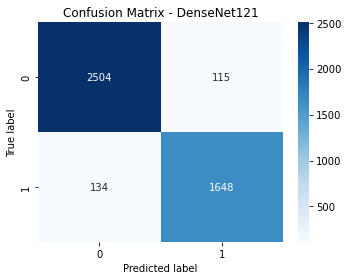

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - DenseNet121")
plt.tight_layout()
plt.show()

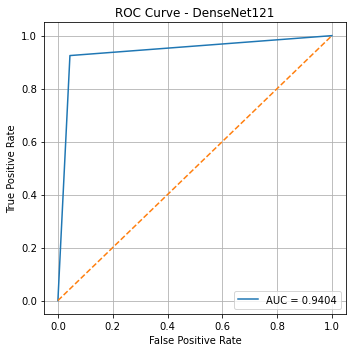

In [15]:
fpr, tpr, thresholds = roc_curve(y_true, y_score)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DenseNet121")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

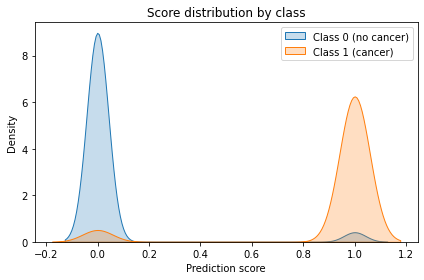

In [16]:
plt.figure(figsize=(6,4))
sns.kdeplot(x=y_score[y_true == 0], label="Class 0 (no cancer)", fill=True)
sns.kdeplot(x=y_score[y_true == 1], label="Class 1 (cancer)", fill=True)
plt.xlabel("Prediction score")
plt.ylabel("Density")
plt.title("Score distribution by class")
plt.legend()
plt.tight_layout()
plt.show()
